# Ejercicio 1: Shocks and Crashes (Lettau & Lydvigson, 2014)

Replicación parcial de Lettau y Lydvigson (2014) "Shocks and Crashes" usando un VECM estructural con la descomposición de Gonzalo-Ng (2001).

**Variables:** `c` (log consumo), `a` (log riqueza financiera), `y` (log ingreso laboral).

**Datos:** `consignas/cay_current.csv` — trimestral, 1952:Q1–2019:Q4.

| Inciso | Tarea | Método |
|--------|-------|--------|
| 1 | Construir `cayt` | DOLS (8 leads/lags) |
| 2 | Estimar VECM(1) | OLS ecuación por ecuación |
| 3 | Identificar shocks | Gonzalo-Ng + Cholesky |
| 4 | Interpretación económica | Análisis IRF |
| 5 | IRF en diferencias | Forma compañera VAR(2) |
| 6 | IRF en niveles | Suma acumulada |
| Bonus | Bandas de confianza | Bootstrap naïve |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import null_space
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

Observations: 271
             c        a        y  cay=c-0.218 a-0.801y+0.441
count  271.000  271.000  271.000                     271.000
mean     9.941   11.763    9.762                       0.000
std      0.437    0.491    0.414                       0.019
min      9.156   10.964    8.980                      -0.049
25%      9.598   11.384    9.454                      -0.012
50%      9.981   11.699    9.796                       0.002
75%     10.364   12.225   10.154                       0.016
max     10.612   12.663   10.400                       0.038


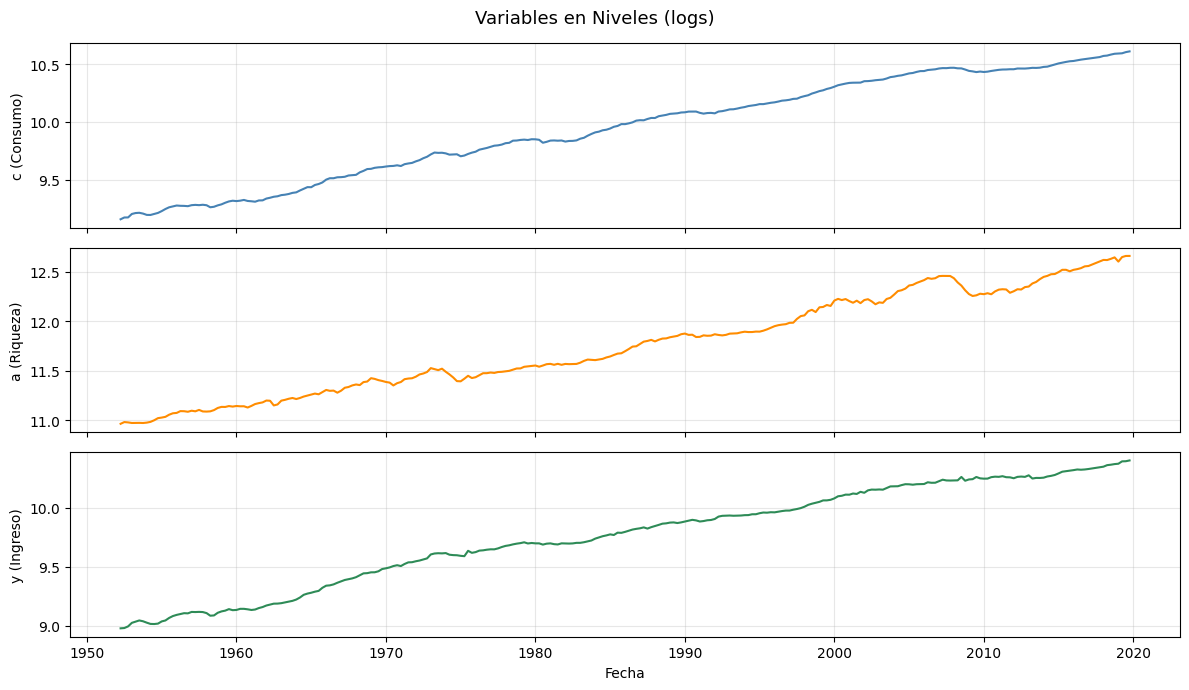

In [2]:
# =====================================================
# LOAD DATA
# =====================================================
df = pd.read_csv('consignas/cay_current.csv', parse_dates=['date'])

# Rename 'w' -> 'a' (wealth/assets) to match exam notation
df = df.rename(columns={'w': 'a'})
df = df.set_index('date')

# Extract series as numpy arrays
c = df['c'].values          # log consumption
a = df['a'].values          # log financial wealth (assets)
y = df['y'].values          # log labor income
cay_lettau = df.iloc[:, -1].values  # Lettau's pre-computed cay
dates = df.index
T = len(c)

# print(f"Sample: {dates[0].strftime('%Y-Q%q') if hasattr(dates[0], 'quarter') else dates[0]} "
#       f"to {dates[-1]}")
print(f"Observations: {T}")
print(df.describe().round(3))

# Plot raw series
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, series, label, color in zip(axes, [c, a, y],
                                     ['c (Consumo)', 'a (Riqueza)', 'y (Ingreso)'],
                                     ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(dates, series, color=color, linewidth=1.5)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
ax.set_xlabel('Fecha')
fig.suptitle('Variables en Niveles (logs)', fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
# =====================================================
# HELPER FUNCTIONS
# =====================================================

def estimate_dols(c, a, y, n_lags=8):
    """
    Dynamic OLS (Stock & Watson) estimation of the cointegrating relationship:

        c_t = k + alpha_a*a_t + alpha_y*y_t
              + sum_{j=1}^{n} [beta_a_j*Da_{t-j} + beta_y_j*Dy_{t-j}]
              + sum_{j=1}^{n} [delta_a_j*Da_{t+j} + delta_y_j*Dy_{t+j}] + u_t

    where Da_t = a_t - a_{t-1}.

    Returns:
        k, alpha_a, alpha_y  : DOLS point estimates
        cayt_full            : cay_t = c_t - alpha_a*a_t - alpha_y*y_t (full sample)
    """
    T = len(c)
    n = n_lags

    # First differences: da[i] = a[i+1] - a[i] for i = 0,...,T-2
    da = np.diff(a)
    dy = np.diff(y)

    # Valid sample for DOLS:
    # Lag j of Da at index t: Da_{t-j} = a[t-j] - a[t-j-1] = da[t-j-1]
    #   Requires t-j-1 >= 0  =>  t >= j+1  =>  t >= n+1
    # Lead j of Da at index t: Da_{t+j} = a[t+j] - a[t+j-1] = da[t+j-1]
    #   Requires t+j-1 <= T-2  =>  t <= T-1-j  =>  t <= T-1-n
    t_start = n + 1          # = 9  (0-indexed, inclusive)
    t_end   = T - 1 - n     # = 263 (0-indexed, inclusive)
    T_eff   = t_end - t_start + 1   # = 255
    t_range = np.arange(t_start, t_end + 1)

    # Build regressor matrix X: (T_eff, 3 + 4*n)
    # Columns: [const, a_t, y_t, lag1_Da,...,lagn_Da, lag1_Dy,...,lagn_Dy,
    #           lead1_Da,...,leadn_Da, lead1_Dy,...,leadn_Dy]
    X = np.zeros((T_eff, 3 + 4 * n))
    X[:, 0] = 1
    X[:, 1] = a[t_range]
    X[:, 2] = y[t_range]

    for j in range(1, n + 1):
        X[:, 2 + j]         = da[t_range - j - 1]   # lag j of Da
        X[:, 2 + n + j]     = dy[t_range - j - 1]   # lag j of Dy
        X[:, 2 + 2*n + j]   = da[t_range + j - 1]   # lead j of Da
        X[:, 2 + 3*n + j]   = dy[t_range + j - 1]   # lead j of Dy

    Y_lhs = c[t_range]

    # OLS
    beta, _, _, _ = np.linalg.lstsq(X, Y_lhs, rcond=None)

    k       = beta[0]
    alpha_a = beta[1]
    alpha_y = beta[2]

    # Construct cay for full sample (not demeaned)
    cayt_full = c - alpha_a * a - alpha_y * y

    return k, alpha_a, alpha_y, cayt_full


def estimate_vecm(c, a, y, cayt, nlags=1):
    """
    Estimate VECM(1) by OLS (equation-by-equation):

        Dx_t = v + gamma*cay_{t-1} + Gamma*Dx_{t-1} + e_t

    where x_t = [c_t, a_t, y_t]'.

    Returns:
        v     : (3,) intercept vector
        gamma : (3,) loading vector on cay_{t-1}
        Gamma : (3,3) coefficient matrix on Dx_{t-1}
        Omega : (3,3) residual covariance matrix
        resid : (3, T_eff) residual matrix
    """
    data = np.array([c, a, y])   # (3, T)
    T    = data.shape[1]
    n    = 3

    # First differences: dx[:,k] = x[k+1] - x[k] = Dx at 0-indexed time k+1
    dx = np.diff(data, axis=1)   # (3, T-1)

    # VECM at 0-indexed time t (t >= 2):
    #   LHS:     dx[:, t-1]     = Dx_t
    #   cay lag: cayt[t-1]      = cay_{t-1}
    #   dx lag:  dx[:, t-2]     = Dx_{t-1}
    # Valid t: 2,...,T-1  =>  T_eff = T-2 observations

    Y_lhs = dx[:, 1:]          # (3, T-2): Dx_2, ..., Dx_{T-1}

    X_rhs = np.zeros((1 + 1 + n, T - 2))
    X_rhs[0, :]  = 1                       # constant
    X_rhs[1, :]  = cayt[1:T-1]             # cay_{t-1}: cay_1,...,cay_{T-2}
    X_rhs[2:, :] = dx[:, :T-2]             # Dx_{t-1}: Dx_1,...,Dx_{T-2}

    # OLS: beta = Y @ X' @ (X @ X')^{-1}
    beta = Y_lhs @ X_rhs.T @ np.linalg.inv(X_rhs @ X_rhs.T)   # (3, 5)

    v     = beta[:, 0]     # (3,)
    gamma = beta[:, 1]     # (3,)
    Gamma = beta[:, 2:]    # (3, 3)

    resid = Y_lhs - beta @ X_rhs   # (3, T-2)
    T_eff = resid.shape[1]
    Omega = (resid @ resid.T) / T_eff   # (3, 3)

    return v, gamma, Gamma, Omega, resid


def gonzalo_ng_identification(gamma, alpha_a, alpha_y, resid, Omega):
    """
    Gonzalo-Ng (2001) identification:

        G = [gamma_perp' ;  alpha']   (3x3)

    where:
      - alpha = [1, -alpha_a, -alpha_y]  (cointegrating vector)
      - gamma_perp (2x3) spans the null space of gamma  (satisfies gamma_perp @ gamma = 0)

    Canonical gamma_perp (Section 4.2): insignificant components of gamma are
    thresholded to zero before computing the null space, yielding basis vectors
    with zeros and ones where possible (easier economic interpretation).

    Structural shocks: eta_t = H^{-1} @ G @ e_t
    where H = chol(G @ Omega @ G').  Rows 0-1 are permanent; row 2 is transitory.

    Returns:
        G, H, H_inv, G_inv : identification matrices
        eta                : (3, T_eff) structural shocks
    """
    # Cointegrating vector
    alpha = np.array([1.0, -alpha_a, -alpha_y])

    # Canonical γ_⊥ following Gonzalo-Ng (2001) Section 4.2:
    # Threshold insignificant components of gamma before computing the null space.
    # This yields a canonical basis with zeros and ones where possible,
    # making the permanent shocks easier to interpret economically.
    threshold    = 0.30   # relative: |γ_i|/||γ|| < threshold → set to 0
    gamma_norm   = np.abs(gamma) / np.linalg.norm(gamma)
    gamma_thresh = gamma.copy()
    gamma_thresh[gamma_norm < threshold] = 0.0
    gamma_perp = null_space(gamma_thresh.reshape(1, -1)).T   # (2, 3)

    # G matrix
    G = np.vstack([gamma_perp, alpha.reshape(1, -1)])   # (3, 3)

    if np.linalg.matrix_rank(G) < 3:
        raise ValueError("G matrix is singular — check identification assumptions.")

    G_inv = np.linalg.inv(G)

    # Variance of u_t = G @ e_t
    Sigma_u = G @ Omega @ G.T

    # Cholesky: Sigma_u = H @ H' (lower triangular)
    H     = np.linalg.cholesky(Sigma_u)
    H_inv = np.linalg.inv(H)

    # Structural shocks: eta_t = H^{-1} @ G @ e_t
    u   = G @ resid          # (3, T_eff)
    eta = H_inv @ u          # (3, T_eff)

    return G, H, H_inv, G_inv, eta


def compute_irf_vecm(Gamma, gamma, alpha_a, alpha_y, G, H, nperiods=41):
    """
    Compute impulse responses of x_t (levels) and Dx_t (differences)
    via the VAR(2)-in-levels companion form.

    VECM(1):  Dx_t = v + gamma*cay_{t-1} + Gamma*Dx_{t-1} + e_t
    is equivalent to VAR(2) in levels:
        x_t = A1*x_{t-1} + A2*x_{t-2} + v + e_t
    where A1 = I + gamma*alpha' + Gamma,  A2 = -Gamma.

    Structural impact matrix (in differences): A0_struct = G^{-1} @ H

    irf_levels[h, var, shock] = response of x_{var} at horizon h to unit shock_{shock}
    irf_diff[h, var, shock]   = response of Dx_{var} at horizon h
    """
    n = 3
    alpha = np.array([1.0, -alpha_a, -alpha_y])

    # VAR(2) coefficient matrices
    A1 = np.eye(n) + np.outer(gamma, alpha) + Gamma   # (3,3)
    A2 = -Gamma                                         # (3,3)

    # Structural impact matrix (how much Dx changes on impact)
    G_inv      = np.linalg.inv(G)
    A0_struct  = G_inv @ H                              # (3,3)

    # Companion matrix: B (6x6), state = [x_t; x_{t-1}]
    B = np.zeros((2*n, 2*n))
    B[:n, :n]  = A1
    B[:n, n:]  = A2
    B[n:, :n]  = np.eye(n)

    # Impact on companion state: Q_struct (6x3)
    Q_struct = np.zeros((2*n, n))
    Q_struct[:n, :] = A0_struct

    # Compute IRF in levels
    irf_levels = np.zeros((nperiods, n, n))   # [h, var, shock]
    B_power    = np.eye(2*n)
    for h in range(nperiods):
        impact             = B_power @ Q_struct
        irf_levels[h, :, :] = impact[:n, :]
        B_power            = B_power @ B

    # IRF in differences: Dirf[h] = irf_levels[h] - irf_levels[h-1]
    irf_diff = np.zeros_like(irf_levels)
    irf_diff[0] = irf_levels[0]
    for h in range(1, nperiods):
        irf_diff[h] = irf_levels[h] - irf_levels[h-1]

    return irf_levels, irf_diff


def plot_irf(irf, var_names, shock_names, title,
             lower=None, upper=None, scale=100):
    """
    Plot impulse response functions.
    irf[h, var, shock] where h=horizon, var=variable, shock=shock index.
    """
    nperiods, nvars, nshocks = irf.shape
    periods = np.arange(nperiods)

    fig, axes = plt.subplots(nvars, nshocks,
                              figsize=(4*nshocks, 3.5*nvars), sharex=True)
    if nvars == 1:
        axes = axes.reshape(1, -1)

    for s in range(nshocks):
        for v in range(nvars):
            ax = axes[v, s]
            irf_vs = irf[:, v, s] * scale

            if lower is not None and upper is not None:
                ax.fill_between(periods,
                                lower[:, v, s] * scale,
                                upper[:, v, s] * scale,
                                color='lightsteelblue', alpha=0.4, label='90% CI')
                ax.plot(periods, lower[:, v, s] * scale,
                        'b--', linewidth=0.8)
                ax.plot(periods, upper[:, v, s] * scale,
                        'b--', linewidth=0.8)

            ax.plot(periods, irf_vs, color='royalblue', linewidth=2)
            ax.axhline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.5)
            ax.set_title(f'Resp. de {var_names[v]}\na {shock_names[s]}',
                         fontsize=9)
            ax.set_xlabel('Trimestres')
            ax.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


print("Funciones cargadas correctamente.")

Funciones cargadas correctamente.


---
## Inciso 1: Construcción de `cayt` por DOLS

**Método:** Dynamic OLS (Stock & Watson). Regresión de $c_t$ sobre niveles de $a_t$, $y_t$ más 8 lags y 8 leads de $\Delta a_t$ y $\Delta y_t$:

$$c_t = k + \alpha_a a_t + \alpha_y y_t + \sum_{j=1}^{8}(\beta_{a,j}\Delta a_{t-j} + \beta_{y,j}\Delta y_{t-j}) + \sum_{j=1}^{8}(\delta_{a,j}\Delta a_{t+j} + \delta_{y,j}\Delta y_{t+j}) + u_t$$

**Resultado:** $\hat{\alpha}_a$, $\hat{\alpha}_y$ y la serie $cay_t = c_t - \hat{\alpha}_a a_t - \hat{\alpha}_y y_t$.

DOLS — Cointegrating Coefficients
  Intercept  k    = -0.4482
  alpha_a         = 0.2163   (Lettau: 0.218)
  alpha_y         = 0.8035   (Lettau: 0.801)

Note: Small differences expected due to extended sample (2019 vs 2001).


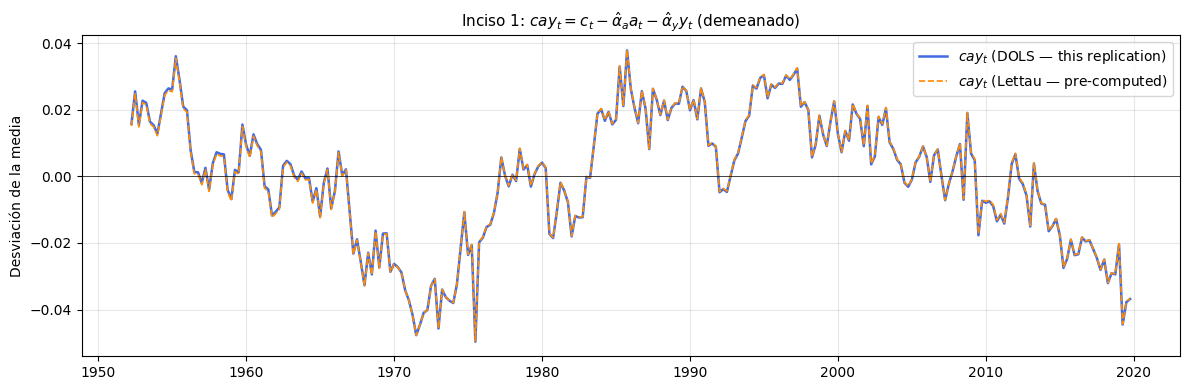

In [4]:
# =====================================================
# INCISO 1: DOLS
# =====================================================
k_dols, alpha_a, alpha_y, cayt_full = estimate_dols(c, a, y, n_lags=8)

print("=" * 40)
print("DOLS — Cointegrating Coefficients")
print("=" * 40)
print(f"  Intercept  k    = {k_dols:.4f}")
print(f"  alpha_a         = {alpha_a:.4f}   (Lettau: 0.218)")
print(f"  alpha_y         = {alpha_y:.4f}   (Lettau: 0.801)")
print("\nNote: Small differences expected due to extended sample (2019 vs 2001).")

# Demean cayt for plotting
cayt_demeaned = cayt_full - cayt_full.mean()

# Plot: my cayt vs Lettau's
cay_lettau_demeaned = cay_lettau - cay_lettau.mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, cayt_demeaned,        color='royalblue',   linewidth=1.8,
        label='$cay_t$ (DOLS — this replication)')
ax.plot(dates, cay_lettau_demeaned,  color='darkorange',  linewidth=1.2,
        linestyle='--', label='$cay_t$ (Lettau — pre-computed)')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('Inciso 1: $cay_t = c_t - \\hat{\\alpha}_a a_t - \\hat{\\alpha}_y y_t$ (demeanado)',
             fontsize=11)
ax.set_ylabel('Desviación de la media')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Inciso 2: Estimación del VECM(1)

**Modelo en forma reducida:**

$$\Delta x_t = v + \gamma \cdot cay_{t-1} + \Gamma \cdot \Delta x_{t-1} + e_t, \quad e_t \sim (0, \Omega)$$

donde $x_t = [c_t, a_t, y_t]'$.  
Comparar con **Tabla 2** de Lettau y Lydvigson (2014).

In [5]:
# =====================================================
# INCISO 2: VECM ESTIMATION
# =====================================================
v_vec, gamma, Gamma, Omega, resid = estimate_vecm(c, a, y, cayt_full)

var_names   = ['c', 'a', 'y']
shock_names = ['Perm. 1 (TFP)', 'Perm. 2 (Labor Share)', 'Transitorio']

print("=" * 55)
print("INCISO 2 — VECM(1) Results  (comparable to Table 2)")
print("=" * 55)

print("\nIntercept v:")
for i, vn in enumerate(var_names):
    print(f"  v_{vn}  = {v_vec[i]: .4f}")

print("\nLoading vector gamma (on cay_{t-1}):")
for i, vn in enumerate(var_names):
    print(f"  gamma_{vn} = {gamma[i]: .4f}")
print("  (Insignificant components set to 0 for Gonzalo-Ng; see Inciso 3)")

print("\nLagged difference matrix Gamma:")
header = "         " + "  ".join([f"D{vn}(-1)".rjust(10) for vn in var_names])
print(header)
for i, vn in enumerate(var_names):
    row = f"  D{vn}:  " + "  ".join([f"{Gamma[i,j]: .4f}".rjust(10) for j in range(3)])
    print(row)

print("\nResidual covariance Omega (x 10^4):")
for i in range(3):
    row = "  " + "  ".join([f"{Omega[i,j]*1e4: .4f}" for j in range(3)])
    print(row)

INCISO 2 — VECM(1) Results  (comparable to Table 2)

Intercept v:
  v_c  = -0.0044
  v_a  =  0.0432
  v_y  =  0.0123

Loading vector gamma (on cay_{t-1}):
  gamma_c = -0.0164
  gamma_a =  0.0860
  gamma_y =  0.0193
  (Insignificant components set to 0 for Gonzalo-Ng; see Inciso 3)

Lagged difference matrix Gamma:
             Dc(-1)      Da(-1)      Dy(-1)
  Dc:      0.1340      0.1194      0.1755
  Da:      0.2045      0.1674     -0.1219
  Dy:      0.3427      0.0613     -0.1171

Residual covariance Omega (x 10^4):
   0.3673   0.2402   0.2410
   0.2402   2.5297   0.2054
   0.2410   0.2054   0.6869


---
## Inciso 3: Identificación de Shocks — Descomposición Gonzalo-Ng

**Teoría (Gonzalo & Ng, 2001):**  
Construir la matriz $G = [\gamma_\perp'; \alpha']$ donde:
- $\alpha = [1, -\hat{\alpha}_a, -\hat{\alpha}_y]'$ — vector de cointegración
- $\gamma_\perp$ (2×3) — espacio nulo de $\gamma'$ (satisface $\gamma_\perp \gamma = 0$)

**Shocks antes de ortogonalizar:**
$$u_t = G e_t = \begin{bmatrix} u_t^{P_1} \\ u_t^{P_2} \\ u_t^{T} \end{bmatrix}$$

**Ortogonalización** vía Cholesky: $H = \text{chol}(G\Omega G')$, entonces $\eta_t = H^{-1} G e_t$.

In [6]:
# =====================================================
# INCISO 3: GONZALO-NG IDENTIFICATION
# =====================================================
G, H, H_inv, G_inv, eta = gonzalo_ng_identification(
    gamma, alpha_a, alpha_y, resid, Omega)

# Dates for residual sample
# VECM uses t=2,...,T-1 (0-indexed) => dates from index 2
dates_resid = dates[2:]

print("=" * 45)
print("Gonzalo-Ng Identification")
print("=" * 45)
print(f"\nCointegrating vector alpha = [1, -{alpha_a:.3f}, -{alpha_y:.3f}]")
print(f"\nG matrix (3x3):")
for row in G:
    print("  " + "  ".join([f"{x: .4f}" for x in row]))
print(f"\nrank(G) = {np.linalg.matrix_rank(G)} (must be 3)")
print(f"\nH matrix (Cholesky of G*Omega*G'):")
for row in H:
    print("  " + "  ".join([f"{x: .6f}" for x in row]))
print("\nVariance check: E[eta*eta'] should be ~I")
Sigma_eta = (eta @ eta.T) / eta.shape[1]
for row in Sigma_eta:
    print("  " + "  ".join([f"{x: .4f}" for x in row]))

Gonzalo-Ng Identification

Cointegrating vector alpha = [1, -0.216, -0.803]

G matrix (3x3):
  -1.0000   0.0000   0.0000
   0.0000   0.0000   1.0000
   1.0000  -0.2163  -0.8035

rank(G) = 3 (must be 3)

H matrix (Cholesky of G*Omega*G'):
   0.006061   0.000000   0.000000
  -0.003977   0.007271   0.000000
  -0.002008  -0.005985   0.003329

Variance check: E[eta*eta'] should be ~I
   1.0000   0.0000  -0.0000
   0.0000   1.0000  -0.0000
  -0.0000  -0.0000   1.0000


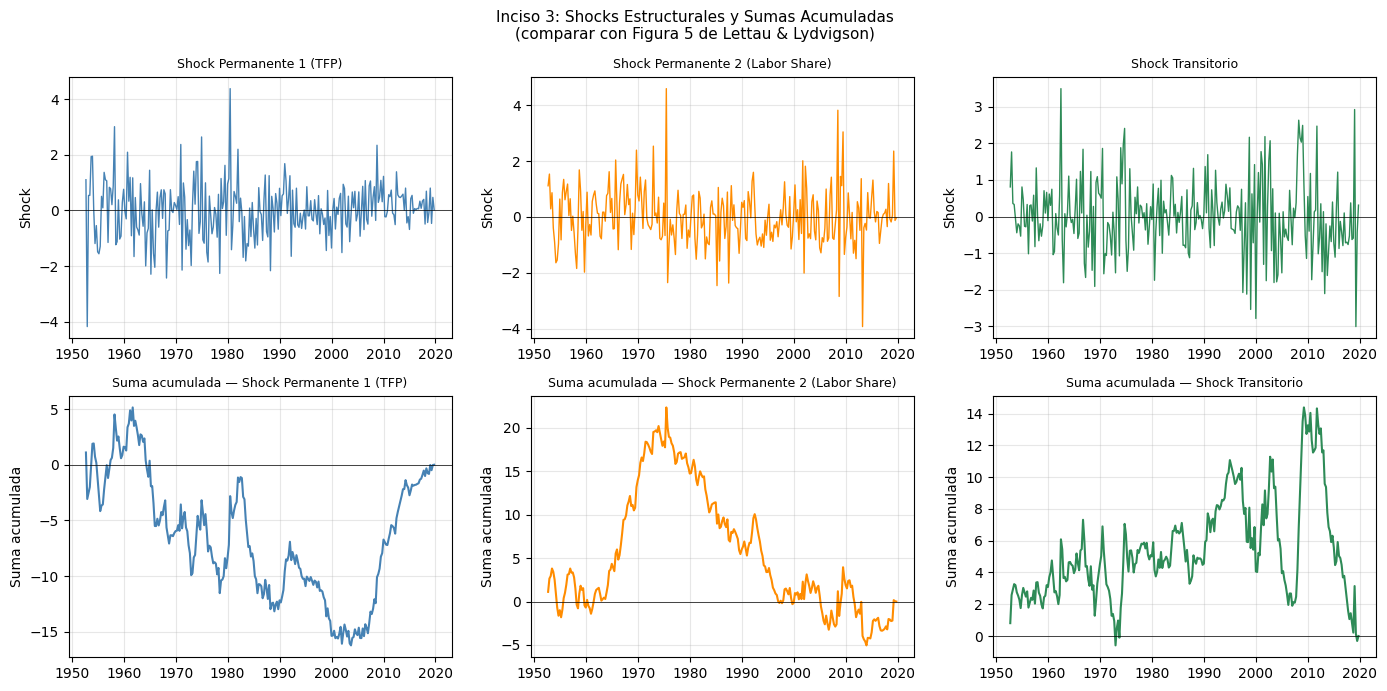

In [7]:
# Plot structural shocks and cumulative sums
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

shock_labels = ['Shock Permanente 1 (TFP)',
                'Shock Permanente 2 (Labor Share)',
                'Shock Transitorio']
colors = ['steelblue', 'darkorange', 'seagreen']

for s in range(3):
    # Top row: shock series
    ax = axes[0, s]
    ax.plot(dates_resid, eta[s], color=colors[s], linewidth=1.0)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_title(shock_labels[s], fontsize=9)
    ax.set_ylabel('Shock')
    ax.grid(True, alpha=0.3)

    # Bottom row: cumulative sum
    ax = axes[1, s]
    ax.plot(dates_resid, np.cumsum(eta[s]), color=colors[s], linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_title(f'Suma acumulada — {shock_labels[s]}', fontsize=9)
    ax.set_ylabel('Suma acumulada')
    ax.grid(True, alpha=0.3)

fig.suptitle('Inciso 3: Shocks Estructurales y Sumas Acumuladas\n'
             '(comparar con Figura 5 de Lettau & Lydvigson)',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Inciso 4: Interpretación Económica de los Shocks

Lettau y Lydvigson (2014) interpretan los dos shocks permanentes y el transitorio de la siguiente manera, basándose en las funciones impulso-respuesta (Inciso 6):

### Shock Permanente 1 → **Shock de Productividad (TFP)**

- Tiene efectos **permanentes y positivos** sobre $c_t$, $a_t$ e $y_t$ en el largo plazo.
- El efecto sobre el ingreso $y_t$ es el más grande y persistente, reflejando un aumento en la capacidad productiva de la economía.
- Afecta positivamente la riqueza financiera $a_t$ porque mejora los fundamentos de los activos.
- Es consistente con un shock de oferta agregada de largo plazo.

### Shock Permanente 2 → **Shock de Participación Laboral (Labor Share)**

- Tiene efectos **permanentes pero asimétricos** sobre las variables.
- Redistribuye entre capital y trabajo: puede aumentar la riqueza financiera mientras reduce el ingreso laboral (o viceversa).
- No afecta la productividad total de la economía pero sí la distribución del ingreso entre factores.
- Captura cambios estructurales en el mercado laboral (e.g., automatización, poder sindical).

### Shock Transitorio → **Shock de Demanda / Financiero**

- Sus efectos **se disipan en el largo plazo**: la variable $cay_t$ revierte a su media (cointegración).
- Genera desvíos temporales en la relación consumo-riqueza-ingreso.
- Lettau y Lydvigson lo asocian con crashes financieros y episodios de euforia bursátil (e.g., dot-com bubble, crisis 2008).
- La suma acumulada de este shock captura el componente transitorio de la riqueza financiera.

**Verificación formal:** Ver las IRF en niveles (Inciso 6) — los shocks permanentes generan respuestas que no vuelven a cero, el transitorio sí.

---
## Inciso 5: Funciones Impulso-Respuesta en Diferencias

**Definición:**
$$IR^{\Delta x}_j = E_t[\Delta x_{t+j}] - E_{t-1}[\Delta x_{t+j}]$$

Se computan vía la forma compañera del VAR(2) en niveles equivalente al VECM:
$$x_t = A_1 x_{t-1} + A_2 x_{t-2} + v + e_t$$
con $A_1 = I + \gamma\alpha' + \Gamma$, $A_2 = -\Gamma$.

$IR^{\Delta x}_h = IR^{x}_h - IR^{x}_{h-1}$

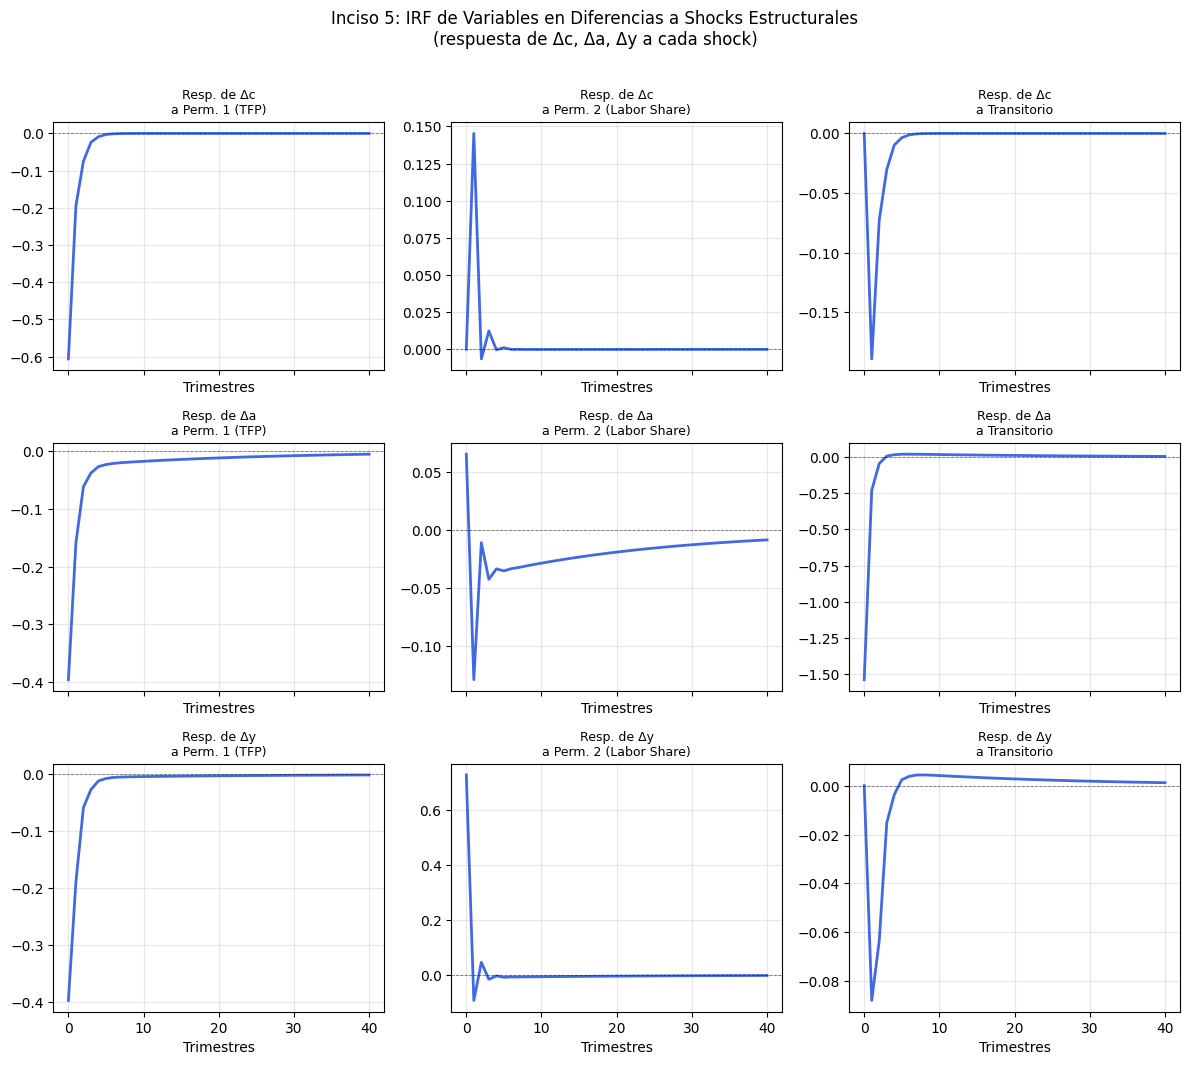

In [8]:
# =====================================================
# INCISO 5: IRF en diferencias
# =====================================================
nperiods = 41
irf_levels, irf_diff = compute_irf_vecm(
    Gamma, gamma, alpha_a, alpha_y, G, H, nperiods=nperiods)

# var_names and shock_names defined above
diff_var_names = ['Δc', 'Δa', 'Δy']

plot_irf(irf_diff, diff_var_names, shock_names,
         title='Inciso 5: IRF de Variables en Diferencias a Shocks Estructurales\n'
               '(respuesta de Δc, Δa, Δy a cada shock)',
         scale=100)

---
## Inciso 6: Funciones Impulso-Respuesta en Niveles

**Definición:**
$$IR^{x}_j = E_t[x_{t+j}] - E_{t-1}[x_{t+j}] = \sum_{i=0}^{j} IR^{\Delta x}_i$$

Los shocks **permanentes** generan respuestas que no regresan a cero en el largo plazo.  
El shock **transitorio** genera respuestas que se disipan.

Comparar con **Figura 4** de Lettau y Lydvigson (2014).

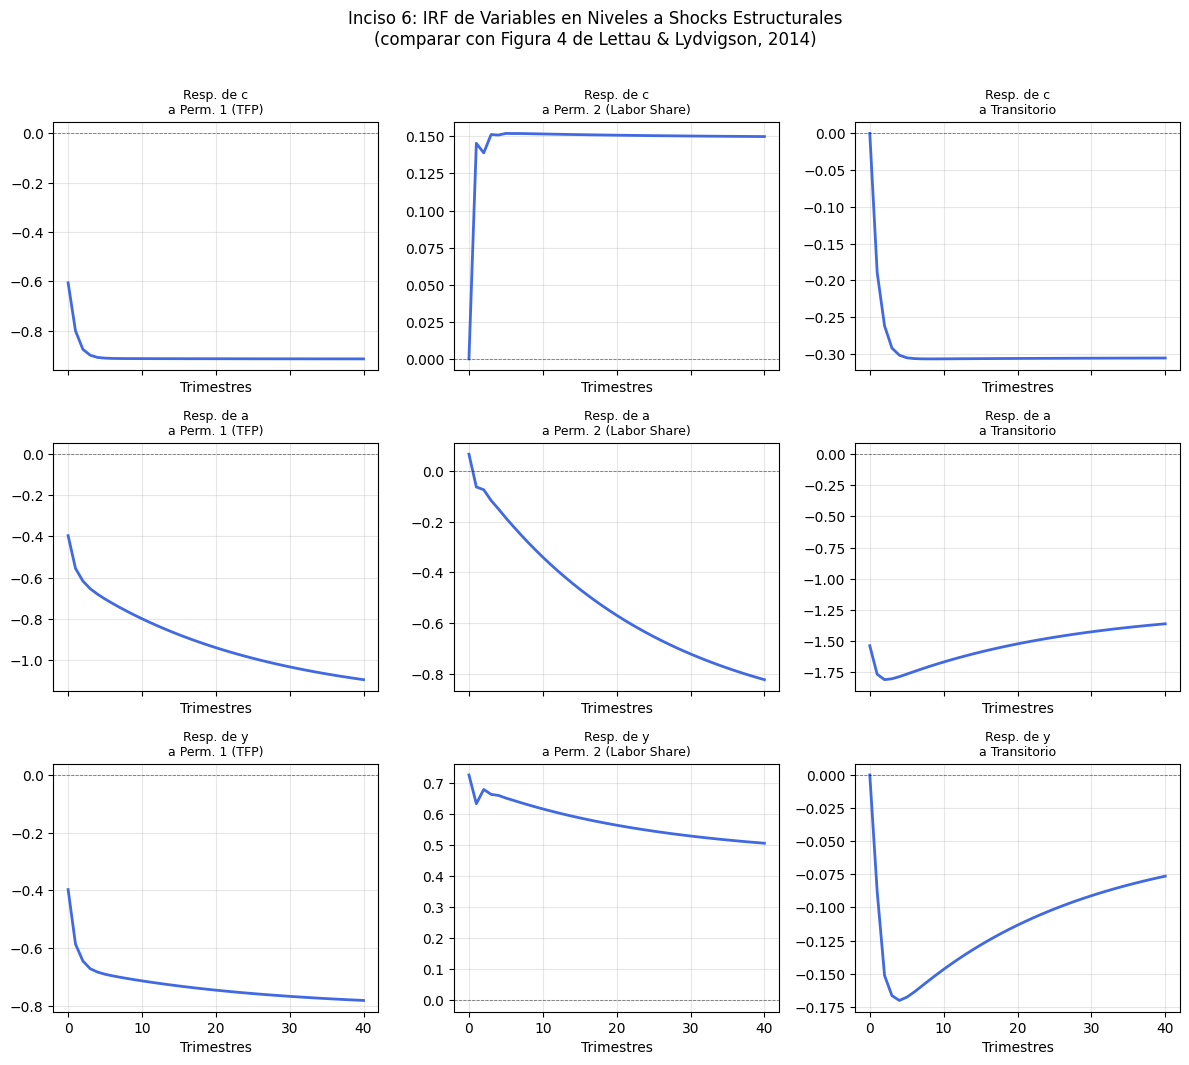

Long-run effects (horizon h=40):
---------------------------------------------
                             Perm.1              Perm.2              Trans.
  c                         -0.915               0.150              -0.305
  a                         -1.096              -0.822              -1.363
  y                         -0.782               0.507              -0.076
(Permanent shocks should have non-zero long-run effects on levels; transitory should converge to zero)


In [9]:
# =====================================================
# INCISO 6: IRF en niveles
# =====================================================
plot_irf(irf_levels, var_names, shock_names,
         title='Inciso 6: IRF de Variables en Niveles a Shocks Estructurales\n'
               '(comparar con Figura 4 de Lettau & Lydvigson, 2014)',
         scale=100)

# Summary of long-run effects
print("Long-run effects (horizon h=40):")
print("-" * 45)
print(f"{'':15s}" + "".join([f"{sn:>20s}" for sn in ['Perm.1','Perm.2','Trans.']]))
for i, vn in enumerate(var_names):
    vals = [f"{irf_levels[40, i, s]*100: .3f}" for s in range(3)]
    print(f"  {vn:12s}" + "".join([f"{v:>20s}" for v in vals]))
print("(Permanent shocks should have non-zero long-run effects on levels; "
      "transitory should converge to zero)")

---
## Bonus: Bandas de Confianza Bootstrap (Naïve)

Siguiendo la metodología del curso (Blanchard-Quah class):
1. Re-samplear residuos $\hat{e}_t$ con reemplazo.
2. Regenerar series artificiales con el VECM estimado.
3. Re-estimar VECM y re-identificar shocks (Gonzalo-Ng).
4. Computar IRF para cada réplica.
5. Calcular percentiles 5% y 95% como bandas de confianza.

**Nota:** Se aplica el bootstrap a las IRF en niveles.

Naive bootstrap: 1000 draws, 90% confidence bands...
  Draw 0/1000
  Draw 100/1000
  Draw 200/1000
  Draw 300/1000
  Draw 400/1000
  Draw 500/1000
  Draw 600/1000
  Draw 700/1000
  Draw 800/1000
  Draw 900/1000


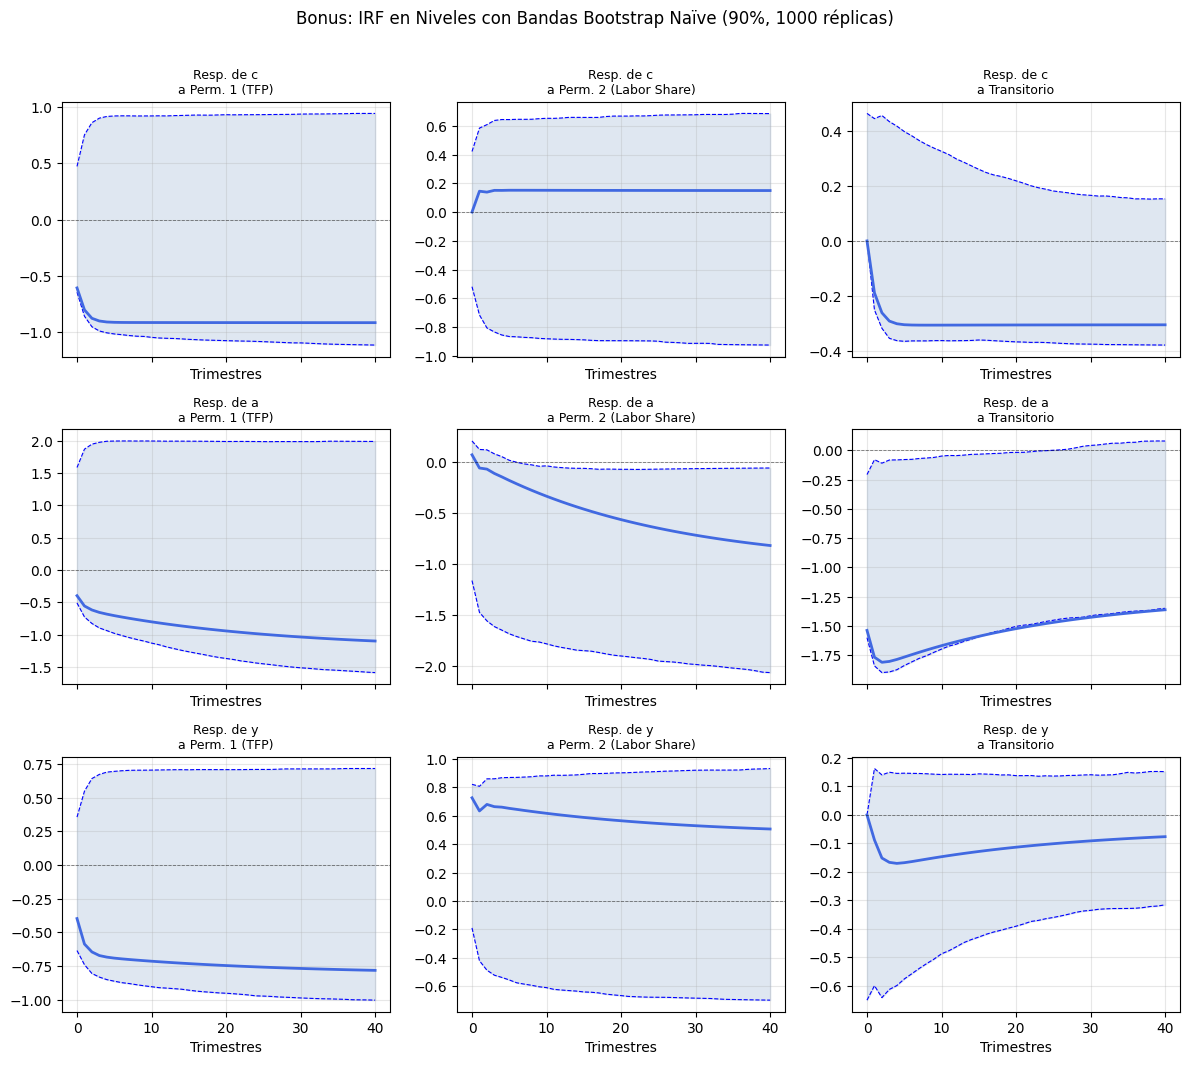

In [10]:
# =====================================================
# BONUS: NAIVE BOOTSTRAP
# =====================================================

def bootstrap_confidence_bands(c, a, y, cayt, v_vec, gamma, Gamma, resid,
                                alpha_a, alpha_y, ndraws=500, nperiods=41,
                                confidence=90):
    """
    Naive bootstrap for VECM impulse responses.
    Re-samples residuals, regenerates artificial data, re-estimates VECM
    and Gonzalo-Ng identification, then collects IRF draws.
    """
    print(f"Naive bootstrap: {ndraws} draws, {confidence}% confidence bands...")
    n       = 3
    T       = len(c)
    T_eff   = resid.shape[1]
    data    = np.array([c, a, y])   # (3, T)

    irf_levels_draws = np.zeros((nperiods, n, n, ndraws))

    for draw in range(ndraws):
        if draw % 100 == 0:
            print(f"  Draw {draw}/{ndraws}")

        # Bootstrap residuals
        idx    = np.random.randint(0, T_eff, T_eff)
        u_boot = resid[:, idx]   # (3, T_eff)

        # Regenerate artificial data from VECM
        # data_boot[:,t] = x_t  (3, T)
        data_boot = np.zeros((n, T))
        data_boot[:, :2] = data[:, :2]   # keep first 2 obs as initial values

        for t in range(2, T):
            # cay_{t-1} using the boot cointegrating relation
            cay_lag_boot = (data_boot[0, t-1]
                            - alpha_a * data_boot[1, t-1]
                            - alpha_y * data_boot[2, t-1])
            dx_lag = data_boot[:, t-1] - data_boot[:, t-2]   # Dx_{t-1}
            # VECM: x_t = x_{t-1} + v + gamma*cay_{t-1} + Gamma*Dx_{t-1} + u_boot
            dx_t = (v_vec
                    + gamma * cay_lag_boot
                    + Gamma @ dx_lag
                    + u_boot[:, t-2])
            data_boot[:, t] = data_boot[:, t-1] + dx_t

        # Re-estimate VECM on artificial data
        c_b, a_b, y_b = data_boot[0], data_boot[1], data_boot[2]

        # Reconstruct cay for boot data using original alpha
        cayt_boot = c_b - alpha_a * a_b - alpha_y * y_b

        try:
            v_b, gamma_b, Gamma_b, Omega_b, resid_b = estimate_vecm(
                c_b, a_b, y_b, cayt_boot)
            G_b, H_b, H_inv_b, G_inv_b, eta_b = gonzalo_ng_identification(
                gamma_b, alpha_a, alpha_y, resid_b, Omega_b)
            irf_lev_b, _ = compute_irf_vecm(
                Gamma_b, gamma_b, alpha_a, alpha_y, G_b, H_b, nperiods=nperiods)
            irf_levels_draws[:, :, :, draw] = irf_lev_b
        except Exception:
            # If identification fails, use last successful draw
            if draw > 0:
                irf_levels_draws[:, :, :, draw] = irf_levels_draws[:, :, :, draw-1]

    alpha_pct = (100 - confidence) / 2
    lower = np.percentile(irf_levels_draws, alpha_pct,       axis=3)
    upper = np.percentile(irf_levels_draws, 100 - alpha_pct, axis=3)

    return lower, upper


# Run bootstrap with 1000 draws for final results
NDRAWS = 1000

lower_boot, upper_boot = bootstrap_confidence_bands(
    c, a, y, cayt_full, v_vec, gamma, Gamma, resid,
    alpha_a, alpha_y,
    ndraws=NDRAWS, nperiods=nperiods, confidence=90
)

plot_irf(irf_levels, var_names, shock_names,
         title=f'Bonus: IRF en Niveles con Bandas Bootstrap Naïve (90%, {NDRAWS} réplicas)',
         lower=lower_boot, upper=upper_boot, scale=100)